<a href="https://colab.research.google.com/github/RekhaThota22/credit-card-customer-segmentation-clustering/blob/main/Credit_card_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importing libraries
import numpy as np
import pandas as pd


In [4]:
df = pd.read_csv('/content/Credit card.csv')

In [5]:
# Data Inspection:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [7]:
df.shape

(8950, 18)

In [6]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
df.duplicated().sum(

)

np.int64(0)

In [10]:
# droping the identifier
df = df.drop('CUST_ID',axis = 1)

# standardising the col names
df.columns = df.columns.str.strip().str.lower()



In [13]:
# now imputing the nulls with medain as they are numerical columns:
df['credit_limit'] = df['credit_limit'].fillna(df['credit_limit'].median())
df['minimum_payments'] =  df['minimum_payments'].fillna(df['minimum_payments'].median())

In [15]:
df.isnull().sum() # checked whether the imputation succeded or not

,0
balance,0
balance_frequency,0
purchases,0
oneoff_purchases,0
installments_purchases,0
cash_advance,0
purchases_frequency,0
oneoff_purchases_frequency,0
purchases_installments_frequency,0
cash_advance_frequency,0


In [18]:
# Scaling:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [21]:
df_scaled.shape

(8950, 17)

In [22]:
# Elbow method to learn how many clusters needed for the data
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(
      n_clusters = i,
      random_state = 42
  )
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)

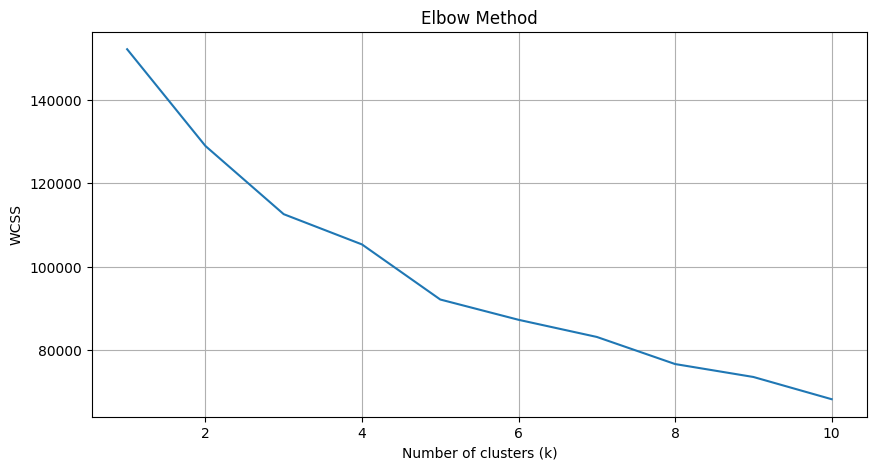

In [44]:
# Visualizing the Elbow method:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10,5))
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid()
plt.show()

In [34]:
# Running silhouette for multiple k
for k in range(2,11):
  kmeans = KMeans(n_clusters = k,
                  random_state = 42)
  labels = kmeans.fit_predict(df_scaled)
  score = silhouette_score(df_scaled,labels)
  print(f'Silhouette score for k = {k}: {score}')

Silhouette score for k = 2: 0.27953987242960154
Silhouette score for k = 3: 0.20671817817880617
Silhouette score for k = 4: 0.1664601900140412
Silhouette score for k = 5: 0.19256596919095406
Silhouette score for k = 6: 0.19229183109910575
Silhouette score for k = 7: 0.21527906424041757
Silhouette score for k = 8: 0.20363733953443425
Silhouette score for k = 9: 0.20375590708205218
Silhouette score for k = 10: 0.21164744068517044


In [35]:
# now fitting kmeans for k = 5
kmeans = KMeans(n_clusters=5,
                random_state = 42)
clusters = kmeans.fit_predict(df_scaled)
df['clusters'] = clusters

In [37]:
df['clusters'].value_counts()

,count
clusters,
2,3164
3,3047
4,1357
0,987
1,395


In [42]:
# we have to see how the clusters are formed but 17 features which is nearly impossible to plot so lets reduce the dimendions using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_components = pca.fit_transform(df_scaled)
# creating a dataframe out of PCA output
pca_df   = pd.DataFrame(pca_components,columns = ['PC1','PC2'])
pca_df['clusters'] = clusters

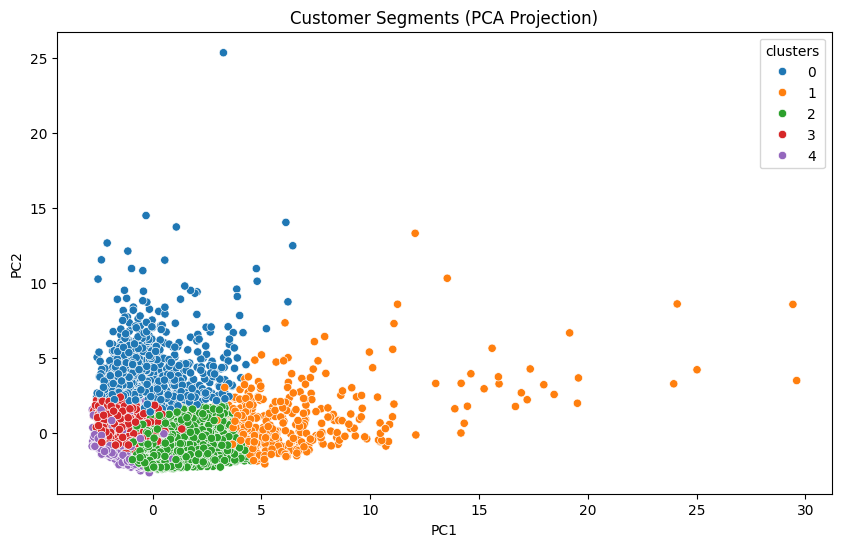

In [45]:
# Lets visualize now
plt.figure(figsize=(10,6))

sns.scatterplot(x = 'PC1',
                y = 'PC2',
                hue = 'clusters',
                data = pca_df,
                palette = 'tab10')
plt.title('Customer Segments (PCA Projection)')
plt.show()

We see lot of overlapping in between the Clusters.

In [47]:
df.groupby('clusters').mean()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
clusters,,,,,,,,,,,,,,,,,
0,4903.428600,0.967095,553.101884,348.463283,204.741611,4983.093638,0.313999,0.153460,0.204131,0.507563,15.499493,8.604863,8062.618587,3858.809663,2071.363910,0.038158,11.413374
1,3588.990384,0.986874,7815.732886,5203.519089,2613.732785,661.788641,0.944730,0.740963,0.785823,0.071074,2.106329,90.351899,9769.620253,7409.095001,1987.582011,0.291103,11.949367
2,930.357741,0.962886,1299.705338,633.167216,666.735496,226.754889,0.897121,0.313579,0.719275,0.044345,0.828382,23.034766,4272.477078,1388.751132,645.167360,0.264987,11.610303
3,1526.118239,0.965743,255.461815,206.435714,49.375189,794.776687,0.159002,0.090819,0.067276,0.160534,3.037742,2.882179,3244.229297,958.642822,804.541051,0.022057,11.508369
4,111.260364,0.381755,335.222822,199.440295,136.001245,325.747598,0.281932,0.072926,0.198278,0.037617,0.788504,4.279293,3687.354049,1076.939244,176.594237,0.233951,11.270450


Here in kmeans as we see the clustering became very poor and most of the custers are overlapping as KMeans feels each and every point to be included into a cluster but DBScan works on density based clustering and if ithe data point falls only into the prescribed epslion radius then only it takes it into cluster and it automatically defines the clusters we dont have to explicitly mention them



In [54]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 1.0,
                min_samples = 5)
db_clusters = dbscan.fit_predict(df_scaled)

In [55]:
pd.Series(db_clusters).value_counts()

,count
0,5797
-1,3082
11,7
8,7
1,6
6,5
12,5
13,5
10,5
2,5


Here DBSCan was not performing well cause which ever datapoint is away from the prescribed eps it would be considered as noise and clearly we can observe the noise is huge (-1 cluster = 3082) and more tiny clusters .This cant help in big financial datasets.